### Previsão de Demanda - Média Móvel

#### Bibliotecas

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import os

from google.colab import drive

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

#### Acessando o Google Drive

In [ ]:
drive.mount('/content/drive')

caminho_base = '/content/drive/MyDrive/Colab Notebooks'

nome_pasta = 'Previsao_Demanda_Avancada'

caminho_completo = os.path.join(
    caminho_base,
    nome_pasta
)

if os.path.exists(caminho_completo):

    print(f'Diretório acessado: {caminho_completo}')

    os.chdir(caminho_completo)

else:

    raise FileNotFoundError(
        'Pasta não encontrada.'
    )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretório acessado: /content/drive/MyDrive/Colab Notebooks/Previsao_Demanda_Avancada


#### Funções

##### Formato Moeda

In [ ]:
def formato_moeda_br(x, pos):

    return (
        f'R$ {x:,.0f}'
        .replace(',', '.')
    )

##### Calcular MMP

In [ ]:
def calcular_mmp(serie, pesos=None ):

    serie = np.array(serie)

    if pesos is None:

        pesos = np.array([ 1, 2, 3, 4, 5, 6 ])

    pesos = pesos / pesos.sum()

    n = len(pesos)

    if len(serie) < n:

        return serie.mean()

    return np.dot(serie[-n:],pesos)


##### Calcular MAPE

In [ ]:
def calcular_mape(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

##### Carregar Dados

In [ ]:
def carregar_dados():

    conn = sqlite3.connect(
        'gestao_estoque.db'
    )
    conn.execute('''
    CREATE INDEX IF NOT EXISTS
    idx_mov_data
    ON Movimentacoes(
        data_movimentacao
    )
    ''')

    query = '''

    SELECT

        m.data_movimentacao,

        m.id_produto,

        p.nome,

        m.quantidade,

        m.valor_total

    FROM Movimentacoes m

    JOIN Produtos p

        ON m.id_produto =
           p.id_produto

    WHERE m.tipo = 'S'

    '''

    df_raw = pd.read_sql_query(
        query,
        conn
    )

    conn.close()

    return df_raw

##### Preparar Serie Temporal

In [ ]:
def preparar_serie_temporal(df_raw):

    df_raw['data_movimentacao'] = pd.to_datetime(df_raw['data_movimentacao'])

    df_raw['mes_ano'] = (df_raw['data_movimentacao'].dt.to_period('M').dt.to_timestamp())

    df_total = (df_raw.groupby('mes_ano').agg({'quantidade': 'sum','valor_total': 'sum'}).reset_index())

    calendario = pd.date_range(start=df_total['mes_ano'].min(),end=df_total['mes_ano'].max(),freq='MS')

    df_total = (df_total.set_index('mes_ano').reindex(calendario).fillna(0).rename_axis('mes_ano').reset_index())

    return df_total


##### Treino Teste

In [ ]:
def separar_treino_teste(
    df,
    horizonte=3
):

    train = df.iloc[:-horizonte]

    test = df.iloc[-horizonte:]

    return train, test

##### Prever Demanda

In [ ]:
def prever_demanda(df_train):

    forecast_mmp = calcular_mmp(df_train['quantidade'])

    X = np.arange(len(df_train)).reshape(-1, 1)

    y = df_train['quantidade'].values

    modelo = LinearRegression()

    modelo.fit(X, y)

    prox_x = np.array([len(df_train)]).reshape(-1, 1)

    forecast_lr = modelo.predict(prox_x)[0]

    forecast_final = (forecast_mmp * 0.5 + forecast_lr * 0.5 )

    return (forecast_final, forecast_mmp, forecast_lr)

##### Calcular Metricas

In [ ]:
def calcular_metricas(real, previsto):

    mae = mean_absolute_error(real, previsto)

    rmse = np.sqrt(mean_squared_error(real, previsto))

    mape = calcular_mape(real, previsto)

    return mae, rmse, mape

##### Plot de Previsão de Quantidade

In [ ]:
def plotar_previsao_quantidade(df_total, forecast, intervalo_inf, intervalo_sup, proximo_mes):

    plt.figure(figsize=(14, 6))

    meses_hist = (df_total['mes_ano'].dt.strftime('%Y-%m').tolist())

    qtd_hist = df_total['quantidade'].tolist()

    mes_prev = proximo_mes.strftime('%Y-%m')

    plt.plot(meses_hist, qtd_hist, marker='o', linewidth=2, label='Histórico')

    plt.plot([meses_hist[-1], mes_prev], [qtd_hist[-1], forecast], linestyle='--', marker='o', linewidth=2, color='red', label='Forecast')

    plt.scatter(mes_prev, forecast, color='red', s=120, zorder=5)

    plt.fill_between([mes_prev], [intervalo_inf], [intervalo_sup], alpha=0.25)

    plt.text(mes_prev, forecast, f'{forecast:,.0f}', fontsize=10, ha='left', va='bottom')

    plt.title('Forecast de Quantidade')

    plt.xlabel('Mês')

    plt.ylabel('Quantidade')

    plt.xticks(rotation=45)

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()


##### Plot Previsão de Valor

In [ ]:
def plotar_previsao_valor(df_total,forecast,proximo_mes):

    plt.figure(figsize=(14, 6))

    meses_hist = (df_total['mes_ano'].dt.strftime('%Y-%m').tolist())

    valor_hist = df_total['valor_total'].tolist()

    mes_prev = proximo_mes.strftime('%Y-%m')

    plt.plot(meses_hist, valor_hist, marker='o', linewidth=2, label='Histórico')

    plt.plot([meses_hist[-1], mes_prev], [valor_hist[-1], forecast], linestyle='--', marker='o', linewidth=2, color='red', label='Forecast')

    plt.scatter(mes_prev, forecast, color='red', s=120)

    plt.text(mes_prev, forecast,f'R$ {forecast:,.0f}'.replace(',', '.'), fontsize=10)

    formatter = FuncFormatter(formato_moeda_br)

    plt.gca().yaxis.set_major_formatter(formatter)

    plt.title('Forecast de Valor')

    plt.xlabel('Mês')

    plt.ylabel('Valor Total')

    plt.xticks(rotation=45)

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()


#### Carregando Dados e Calculando Previsão

In [ ]:
df_raw = carregar_dados()

print(f'Registros carregados: {len(df_raw)}')

Registros carregados: 8801


In [ ]:
df_total = preparar_serie_temporal(df_raw)

print(df_total.head())


     mes_ano  quantidade  valor_total
0 2024-06-01       15066   6260535.19
1 2024-07-01       15637   6433351.20
2 2024-08-01       14992   5895702.36
3 2024-09-01       14934   5998705.04
4 2024-10-01       18647   7704972.91


In [ ]:
train, test = separar_treino_teste(df_total, horizonte=3)

In [ ]:
forecast_qtd, forecast_mmp, forecast_lr = (prever_demanda(train))

In [ ]:
forecast_valor = calcular_mmp(train['valor_total'])

In [ ]:
desvio = train['quantidade'].std()

intervalo_inf = (forecast_qtd - desvio)

intervalo_sup = (forecast_qtd + desvio)

previsoes_teste = []

historico = train.copy()

for i in range(len(test)):

    prev, _, _ = prever_demanda(historico)

    previsoes_teste.append(prev)

    historico = pd.concat([historico,test.iloc[[i]]])


In [ ]:
mae, rmse, mape = calcular_metricas(test['quantidade'],previsoes_teste)

print('\n==========================')
print('MÉTRICAS')
print('==========================')

print(f'MAE  : {mae:,.2f}')

print(f'RMSE : {rmse:,.2f}')

print(f'MAPE : {mape:.2f}%')



MÉTRICAS
MAE  : 800.61
RMSE : 1,075.41
MAPE : 4.08%


In [ ]:

proximo_mes = (df_total['mes_ano'].max()+ pd.DateOffset(months=1))

print('\n==========================')
print('FORECAST')
print('==========================')

print(f'Próximo mês: 'f'{proximo_mes.strftime("%Y-%m")}')

print(f'Forecast Quantidade: 'f'{forecast_qtd:,.2f}')

print(f'Forecast MMP: 'f'{forecast_mmp:,.2f}')

print(f'Forecast Regressão: 'f'{forecast_lr:,.2f}')

print(f'Forecast Valor: 'f'R$ {forecast_valor:,.2f}')


FORECAST
Próximo mês: 2026-07
Forecast Quantidade: 21,058.33
Forecast MMP: 20,709.95
Forecast Regressão: 21,406.70
Forecast Valor: R$ 8,264,920.91


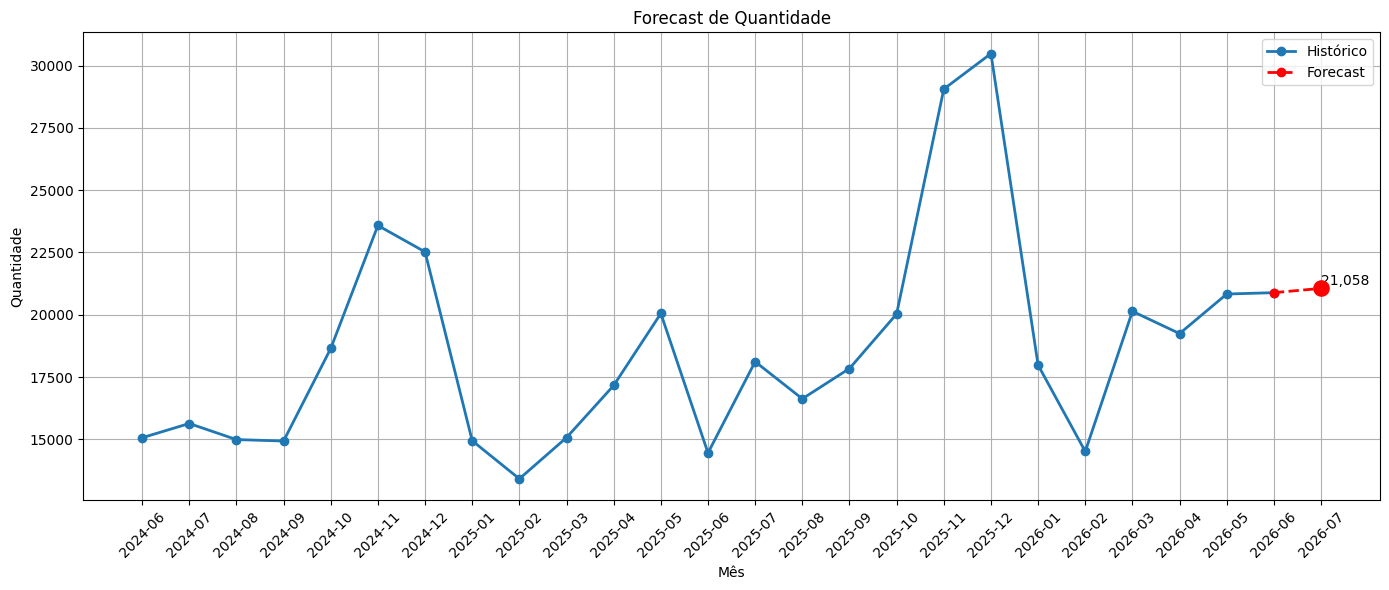

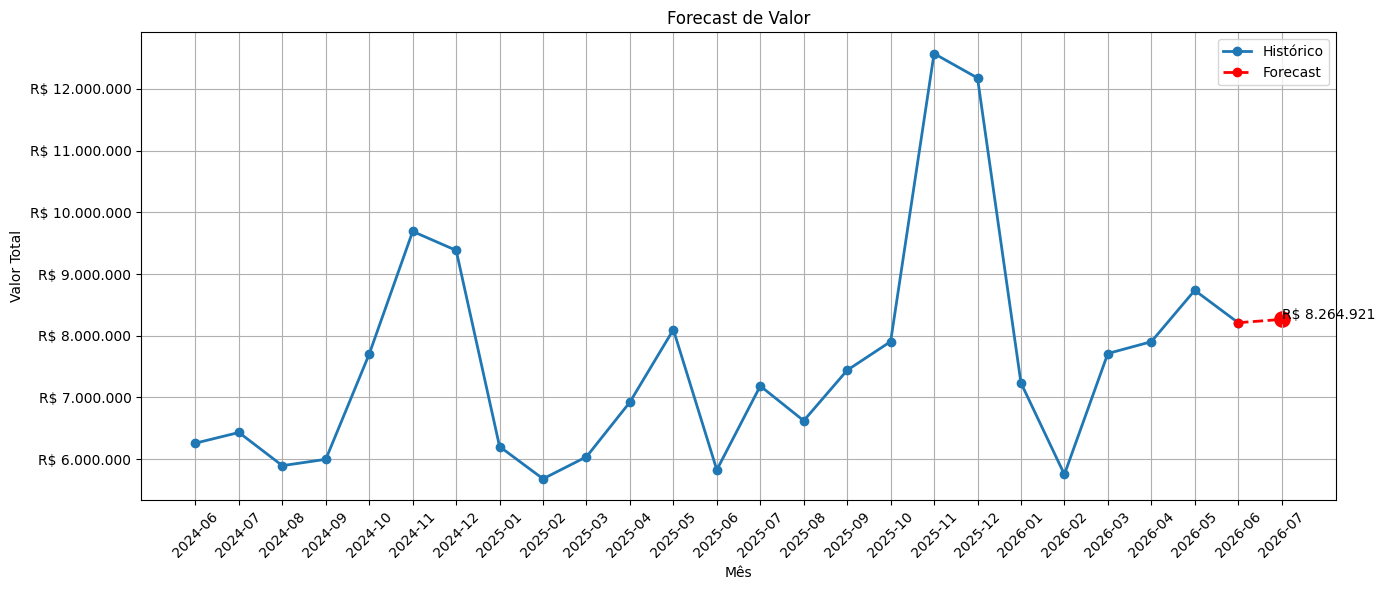

In [ ]:
plotar_previsao_quantidade(df_total, forecast_qtd, intervalo_inf, intervalo_sup, proximo_mes)

plotar_previsao_valor(df_total, forecast_valor, proximo_mes)
